In [13]:
# проверяем GPU и компилятор

!nvidia-smi
!nvcc --version

Tue Mar 31 18:40:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             15W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
# записываем CUDA/C++ программу в файл

%%writefile matrix_lab.cu
#include <iostream>
#include <vector>
#include <random>
#include <chrono>
#include <fstream>
#include <iomanip>
#include <cmath>
#include <algorithm>
#include <cuda_runtime.h>

// Макрос для проверки CUDA-вызовов

#define CUDA_CHECK(call)                                                     \
do {                                                                         \
    cudaError_t err = call;                                                  \
    if (err != cudaSuccess) {                                                \
        std::cerr << "CUDA error: " << cudaGetErrorString(err)               \
                  << " | file: " << __FILE__                                 \
                  << " | line: " << __LINE__ << std::endl;                   \
        exit(1);                                                             \
    }                                                                        \
} while (0)

// Размер блока (тайла) для GPU
const int TILE = 16;

// Заполнение матрицы случайными числами

void fill_random(std::vector<float>& M, int seed) {
    std::mt19937 gen(seed);
    std::uniform_real_distribution<float> dist(-1.0f, 1.0f);

    for (auto& x : M) {
        x = dist(gen);
    }
}

// Умножение матриц на CPU
// Последовательная версия
// Формат хранения: одномерный массив в row-major
// C[i, j] = sum(A[i, k] * B[k, j])

void multiply_cpu(const std::vector<float>& A,
                  const std::vector<float>& B,
                  std::vector<float>& C,
                  int N) {
    std::fill(C.begin(), C.end(), 0.0f);

    // Более кэш-дружелюбный порядок циклов: i-k-j
    for (int i = 0; i < N; ++i) {
        for (int k = 0; k < N; ++k) {
            float a = A[i * N + k];
            for (int j = 0; j < N; ++j) {
                C[i * N + j] += a * B[k * N + j];
            }
        }
    }
}

// Умножение матриц на GPU (CUDA)
//
// Что распараллелено:
// - каждый поток вычисляет один элемент матрицы C
// - блок потоков загружает части A и B в shared memory
// - это уменьшает число обращений к глобальной памяти

__global__ void multiply_gpu_tiled(const float* A,
                                   const float* B,
                                   float* C,
                                   int N) {
    __shared__ float As[TILE][TILE];
    __shared__ float Bs[TILE][TILE];

    int row = blockIdx.y * TILE + threadIdx.y;
    int col = blockIdx.x * TILE + threadIdx.x;

    float sum = 0.0f;

    // Проходим по тайлам
    for (int t = 0; t < (N + TILE - 1) / TILE; ++t) {
        int a_col = t * TILE + threadIdx.x;
        int b_row = t * TILE + threadIdx.y;

        // Загружаем кусок A в shared memory
        if (row < N && a_col < N) {
            As[threadIdx.y][threadIdx.x] = A[row * N + a_col];
        } else {
            As[threadIdx.y][threadIdx.x] = 0.0f;
        }

        // Загружаем кусок B в shared memory
        if (b_row < N && col < N) {
            Bs[threadIdx.y][threadIdx.x] = B[b_row * N + col];
        } else {
            Bs[threadIdx.y][threadIdx.x] = 0.0f;
        }

        __syncthreads();

        // Перемножаем элементы тайлов
        for (int k = 0; k < TILE; ++k) {
            sum += As[threadIdx.y][k] * Bs[k][threadIdx.x];
        }

        __syncthreads();
    }

    if (row < N && col < N) {
        C[row * N + col] = sum;
    }
}

// Вычисление ошибок между CPU и GPU

void compute_errors(const std::vector<float>& ref,
                    const std::vector<float>& test,
                    double& max_abs_err,
                    double& max_rel_err) {
    max_abs_err = 0.0;
    max_rel_err = 0.0;

    for (size_t i = 0; i < ref.size(); ++i) {
        double abs_err = std::fabs((double)ref[i] - (double)test[i]);
        double denom = std::max(std::fabs((double)ref[i]), 1e-6);
        double rel_err = abs_err / denom;

        if (abs_err > max_abs_err) max_abs_err = abs_err;
        if (rel_err > max_rel_err) max_rel_err = rel_err;
    }
}

// Структура для результатов одного эксперимента

struct Result {
    int N;
    double cpu_ms;
    double gpu_kernel_ms;
    double gpu_total_ms;
    double max_abs_err;
    double max_rel_err;
    double speedup_kernel;
    double speedup_total;
    int correct;
};

// Один эксперимент для размера N

Result run_experiment(int N) {
    size_t bytes = (size_t)N * N * sizeof(float);

    // Хостовые матрицы
    std::vector<float> A(N * N);
    std::vector<float> B(N * N);
    std::vector<float> C_cpu(N * N, 0.0f);
    std::vector<float> C_gpu(N * N, 0.0f);

    // Заполняем матрицы одинаково для воспроизводимости
    fill_random(A, 100 + N);
    fill_random(B, 200 + N);

    // ---------------- CPU ----------------
    auto cpu_start = std::chrono::high_resolution_clock::now();
    multiply_cpu(A, B, C_cpu, N);
    auto cpu_end = std::chrono::high_resolution_clock::now();

    double cpu_ms = std::chrono::duration<double, std::milli>(cpu_end - cpu_start).count();

    // ---------------- GPU ----------------
    float *d_A = nullptr, *d_B = nullptr, *d_C = nullptr;
    CUDA_CHECK(cudaMalloc(&d_A, bytes));
    CUDA_CHECK(cudaMalloc(&d_B, bytes));
    CUDA_CHECK(cudaMalloc(&d_C, bytes));

    // Засекаем "полное" GPU-время: копирование + kernel + копирование обратно
    auto gpu_total_start = std::chrono::high_resolution_clock::now();

    CUDA_CHECK(cudaMemcpy(d_A, A.data(), bytes, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_B, B.data(), bytes, cudaMemcpyHostToDevice));

    dim3 block(TILE, TILE);
    dim3 grid((N + TILE - 1) / TILE, (N + TILE - 1) / TILE);

    multiply_gpu_tiled<<<grid, block>>>(d_A, d_B, d_C, N);
    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaDeviceSynchronize());

    // Засекаем "чистое" время kernel
    cudaEvent_t start, stop;
    CUDA_CHECK(cudaEventCreate(&start));
    CUDA_CHECK(cudaEventCreate(&stop));

    CUDA_CHECK(cudaEventRecord(start));
    multiply_gpu_tiled<<<grid, block>>>(d_A, d_B, d_C, N);
    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaEventRecord(stop));
    CUDA_CHECK(cudaEventSynchronize(stop));

    float gpu_kernel_ms_f = 0.0f;
    CUDA_CHECK(cudaEventElapsedTime(&gpu_kernel_ms_f, start, stop));

    CUDA_CHECK(cudaMemcpy(C_gpu.data(), d_C, bytes, cudaMemcpyDeviceToHost));

    auto gpu_total_end = std::chrono::high_resolution_clock::now();
    double gpu_total_ms = std::chrono::duration<double, std::milli>(gpu_total_end - gpu_total_start).count();

    // Проверка корректности
    double max_abs_err = 0.0;
    double max_rel_err = 0.0;
    compute_errors(C_cpu, C_gpu, max_abs_err, max_rel_err);

    // Порог корректности
    int correct = (max_abs_err < 1e-3) ? 1 : 0;

    // Ускорение
    double gpu_kernel_ms = (double)gpu_kernel_ms_f;
    double speedup_kernel = cpu_ms / gpu_kernel_ms;
    double speedup_total  = cpu_ms / gpu_total_ms;

    // Освобождение памяти
    CUDA_CHECK(cudaEventDestroy(start));
    CUDA_CHECK(cudaEventDestroy(stop));
    CUDA_CHECK(cudaFree(d_A));
    CUDA_CHECK(cudaFree(d_B));
    CUDA_CHECK(cudaFree(d_C));

    return {N, cpu_ms, gpu_kernel_ms, gpu_total_ms,
            max_abs_err, max_rel_err,
            speedup_kernel, speedup_total, correct};
}

// ------------------------------
// main
// ------------------------------
int main() {
    std::vector<int> sizes = {100, 250, 500, 750, 1000};

    // Информация об устройстве
    cudaDeviceProp prop;
    CUDA_CHECK(cudaGetDeviceProperties(&prop, 0));
    std::cout << "GPU: " << prop.name << "\n\n";

    // Файл с результатами для построения таблицы/графика в Python
    std::ofstream fout("results.csv");
    fout << "N,cpu_ms,gpu_kernel_ms,gpu_total_ms,max_abs_err,max_rel_err,speedup_kernel,speedup_total,correct\n";

    std::cout << std::left
              << std::setw(8)  << "N"
              << std::setw(15) << "CPU ms"
              << std::setw(18) << "GPU kernel ms"
              << std::setw(16) << "GPU total ms"
              << std::setw(16) << "Speedup k"
              << std::setw(16) << "Speedup tot"
              << std::setw(14) << "MaxAbsErr"
              << std::setw(14) << "MaxRelErr"
              << std::setw(10) << "Correct"
              << "\n";

    std::cout << std::string(125, '-') << "\n";

    for (int N : sizes) {
        Result r = run_experiment(N);

        std::cout << std::left
                  << std::setw(8)  << r.N
                  << std::setw(15) << std::fixed << std::setprecision(3) << r.cpu_ms
                  << std::setw(18) << r.gpu_kernel_ms
                  << std::setw(16) << r.gpu_total_ms
                  << std::setw(16) << r.speedup_kernel
                  << std::setw(16) << r.speedup_total
                  << std::setw(14) << r.max_abs_err
                  << std::setw(14) << r.max_rel_err
                  << std::setw(10) << (r.correct ? "YES" : "NO")
                  << "\n";

        fout << r.N << ","
             << r.cpu_ms << ","
             << r.gpu_kernel_ms << ","
             << r.gpu_total_ms << ","
             << r.max_abs_err << ","
             << r.max_rel_err << ","
             << r.speedup_kernel << ","
             << r.speedup_total << ","
             << r.correct << "\n";
    }

    fout.close();

    std::cout << "\nРезультаты сохранены в файл results.csv\n";
    return 0;
}

Overwriting matrix_lab.cu


In [15]:
#компиляция и запуск

!nvcc -O3 matrix_lab.cu -o matrix_lab
!./matrix_lab

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
GPU: Tesla T4

N       CPU ms         GPU kernel ms     GPU total ms    Speedup k       Speedup tot     MaxAbsErr     MaxRelErr     Correct   
-----------------------------------------------------------------------------------------------------------------------------
100     0.134          0.017             0.336           7.889           0.400           0.000         0.001         YES       
250     2.568          0.079             0.427           32.343          6.008           0.000         0.002         YES       
500     19.313         0.521             2.003           37.104          9.641           0.000         0.014         YES       
750     81.036         1.625             5.168           49.866          15.681          0.000         0.330         YES       
1000    177.895        3.825    

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Читаем результаты
df = pd.read_csv("results.csv")

# Округляем для красивого вывода
display(df.round(4))

,N,cpu_ms,gpu_kernel_ms,gpu_total_ms,max_abs_err,max_rel_err,speedup_kernel,speedup_total,correct
0,100,0.1343,0.0170,0.3360,0.0,0.0005,7.8889,0.3997,1
1,250,2.5678,0.0794,0.4274,0.0,0.0019,32.3431,6.0081,1
2,500,19.3129,0.5205,2.0033,0.0,0.0141,37.1036,9.6407,1
3,750,81.0356,1.6251,5.1678,0.0,0.3304,49.8663,15.6810,1
4,1000,177.8950,3.8250,10.4749,0.0,0.1608,46.5085,16.9829,1


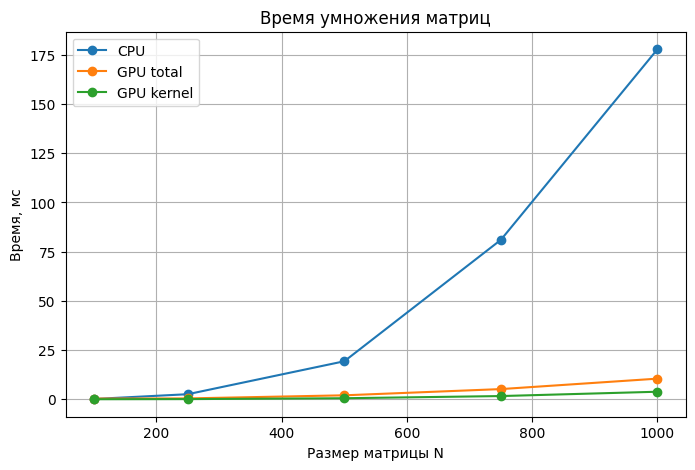

In [17]:
#график для времени выполнения

import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")

plt.figure(figsize=(8, 5))
plt.plot(df["N"], df["cpu_ms"], marker="o", label="CPU")
plt.plot(df["N"], df["gpu_total_ms"], marker="o", label="GPU total")
plt.plot(df["N"], df["gpu_kernel_ms"], marker="o", label="GPU kernel")
plt.xlabel("Размер матрицы N")
plt.ylabel("Время, мс")
plt.title("Время умножения матриц")
plt.grid(True)
plt.legend()
plt.show()

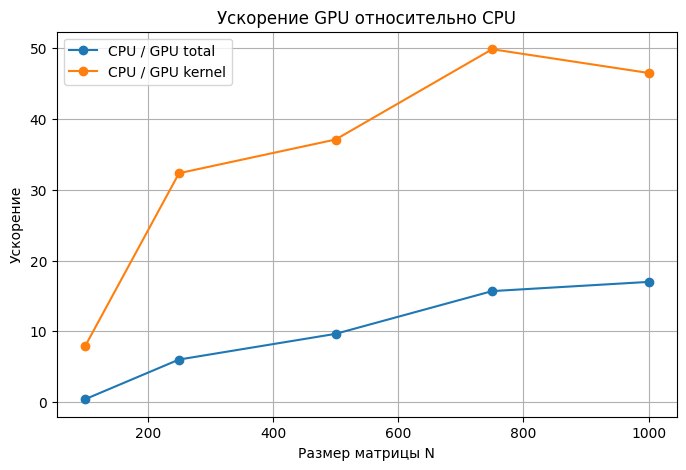

In [18]:
#график ускорения

import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")

plt.figure(figsize=(8, 5))
plt.plot(df["N"], df["speedup_total"], marker="o", label="CPU / GPU total")
plt.plot(df["N"], df["speedup_kernel"], marker="o", label="CPU / GPU kernel")
plt.xlabel("Размер матрицы N")
plt.ylabel("Ускорение")
plt.title("Ускорение GPU относительно CPU")
plt.grid(True)
plt.legend()
plt.show()